# What is Sequence Data?

**Sequence data** is data where the **order of the items matters**.

* Examples:

  * A sentence (order of words matters).
  * A time series (order of days, hours, seconds matters).
  * Music notes (order of notes matters).
  * DNA sequences (order of bases matters).

If you shuffle the order, the meaning or pattern changes.


### **Examples of sequence data**:

1. **Text / Sentences**

   * Words or characters in order:
     Example → `"The cat sat on the mat"`
   * Meaning depends on order → `"cat sat on the mat the"` is not the same.

2. **Stock Prices / Financial Time Series**

   * Daily closing prices, hourly prices, etc.
     Example → `[195, 196, 197, 200, 198, 201, ...]`
   * Tomorrow’s price depends on the pattern of previous days.

3. **Weather Data**

   * Temperature readings over time:
     Example → `[30°C, 31°C, 29°C, 28°C, 32°C, ...]`

4. **Speech / Audio Signals**

   * Waveform values or MFCC features over time.
     Example → `[0.1, 0.4, -0.2, ...]` (audio sample values)

5. **Sensor Data / IoT**

   * Heartbeat signals, accelerometer readings, electricity usage.
     Example → `[72 bpm, 75 bpm, 73 bpm, 70 bpm, ...]`

6. **Video Frames**

   * Sequence of images (frames) played in order.
     Example → frame 1, frame 2, frame 3...

---

👉 **Key Idea**: Sequence data means **the order matters**. If you shuffle it, you lose the meaning.


### Normal (non-sequence) data vs Sequence Data Example

#### **Normal (non-sequence) data**

Imagine a table of customer info:

| Age | Income | City     |
| --- | ------ | -------- |
| 25  | 50k    | New York |

* Here, **order of columns doesn’t matter**.
* Whether you write `[25, 50k, NY]` or `[NY, 25, 50k]`, the information is the same (just rearranged).

---

#### **Sequence data**

Now take a **sentence**:

* Original: *“I love dogs”*
* Shuffled: *“Dogs love I”*

Here, the **order matters** — shuffle the sequence, and the meaning changes completely.

---

**Key Point:**

* Normal data = order doesn’t matter.
* Sequence data = order matters a lot.

---



### Stock Prices as Sequence Data

Suppose you track the closing price of a stock over 5 days:

| Day | Price |
| --- | ----- |
| 1   | 100   |
| 2   | 102   |
| 3   | 105   |
| 4   | 103   |
| 5   | 106   |

---

### Why is this **sequence data**?

* The **order of days matters**.
* The price on **Day 5** depends on what happened on Days 1–4.
* If you shuffle the order, the pattern is destroyed:

Shuffled sequence (wrong):

```
Day 3 → 105, Day 1 → 100, Day 5 → 106, ...
```

Now you lose the upward trend — it looks random.

---

### Key takeaway

Stock prices form **sequence data** because:

1. **Order matters** (yesterday’s price influences today’s).
2. **Patterns over time** (trends, cycles) only make sense in the original order.
3. Future predictions require **memory of the past**.

---

### Compare how an **ANN vs. RNN** would see the same stock price sequence.

---

### 📊 Stock Prices (example)

```
Day 1 → 100
Day 2 → 102
Day 3 → 105
Day 4 → 103
Day 5 → 106
```

---

## How ANN (Artificial Neural Network) sees it

* ANN expects **independent inputs**, like a table.
* It might treat stock data like:

```
[100, 102, 105, 103, 106]
```

* Problem: ANN sees them all at once, **ignores order**.
* So to ANN, `[100, 102, 105, 103, 106]` = `[106, 103, 105, 102, 100]`.
* ANN cannot naturally understand “Day 2 comes after Day 1”.
* This loses the idea of **trend over time**.

---

## How RNN (Recurrent Neural Network) sees it

* RNN reads **one day at a time**, like:

```
Input Day 1 → 100
Input Day 2 → 102 (remembers Day 1)
Input Day 3 → 105 (remembers Days 1 & 2)
Input Day 4 → 103 (remembers Days 1–3)
Input Day 5 → 106 (remembers Days 1–4)
```

* At each step, it keeps a **memory** of the past.
* This way, it learns the **sequence pattern** (e.g., "the stock tends to go up after 2 days of growth").
* RNN can then predict **Day 6’s price** using memory of Days 1–5.

---

### Big difference

* **ANN** → good for static data (age, salary, etc.) but bad for sequences.
* **RNN** → designed for sequences (stock prices, sentences, weather).

---


# **Why Artificial Neural Networks (ANNs) struggle with sequence data**

---

## What you already know: ANN basics

* An ANN takes in a **fixed-size input vector** (say 100 features).
* It processes them layer by layer and produces an output.
* It works well for tasks like:

  * Image classification (input = pixels)
  * Tabular data (input = numeric features)

But sequences (text, speech, time series) behave differently.

---

### **Why ANN struggles with sequence data**

---

### 1. **Fixed Input Size Problem**

* ANN expects **all inputs to be of the same size**.
* Example: If your ANN takes 5 numbers, it always wants 5 numbers.
* But in sequences (text, speech, stock prices), the length can vary:

  * Sentence: `"I love cats"` (3 words)
  * Sentence: `"The dog is barking loudly"` (5 words)
* ANN cannot handle this naturally. You’d have to **pad/truncate** everything to the same size → inefficient.

---

### 2. **No Memory of Past Inputs**

* ANN looks at the input all at once and makes a decision.
* It doesn’t **remember what came before**.
* But sequence tasks need memory:

  * `"I went to the bank to deposit money"` vs `"I sat on the bank of the river"`
  * The meaning of **bank** depends on earlier words.
* ANN fails here because it treats every input independently.

---

### 3. **Too Many Parameters (No Parameter Sharing)**

* ANN assigns **separate weights** for each input position.
* Example: If input = `[x1, x2, x3, x4, x5]` → weights for each are different.
* In sequences, the same “logic” should apply across positions.

  * The way you read word 1 should be similar to how you read word 5.
* ANN wastes parameters because it **doesn’t reuse the same weights** across time steps.
* RNN fixes this by **sharing parameters** across steps → same set of weights processes the whole sequence.

---

### 4. **Order is Lost**

* ANN doesn’t understand that **order matters**.
* Example:

  * `"dog bites man"` ≠ `"man bites dog"`
* If you just feed words as inputs, ANN treats them as a bag of numbers.
* It cannot capture “time” or “sequence” unless you **manually add order info**.

---

That’s why RNN (and later LSTM/GRU/Transformers) were invented → they solve these problems by:

* Handling variable input lengths
* Remembering context
* Sharing parameters
* Preserving order

---


### ANN vs RNN: Student Taking an Exam

---

### 1. **Fixed Input Size Problem**

* **ANN student**: *“I can only answer questions if they are exactly 5 sentences long. If the passage is 3 or 10 sentences, I get confused.”*
* **RNN student**: *“Doesn’t matter if the passage is short or long, I’ll read it sentence by sentence.”*

---

### 2. **No Memory of Past Inputs**

* **ANN student**: *“I see each sentence separately, I don’t remember what I read before.”*
* Example: Reads “bank” → doesn’t recall if it was about **money** or **river**.
* **RNN student**: *“I keep a notebook (hidden state) where I jot down key points from earlier, so I remember context when I reach ‘bank’.”*

---

### 3. **Too Many Parameters (No Parameter Sharing)**

* **ANN student**: *“For each sentence position (1st, 2nd, 3rd…), I need a totally different set of study notes. I never reuse them.”*
* **RNN student**: *“I use the **same study method** for every sentence, no matter where it appears. Saves time, saves memory.”*

---

### 4. **Order is Lost**

* **ANN student**: *“I only care about the words I see, not their order. For me, ‘dog bites man’ = ‘man bites dog’.”*
* **RNN student**: *“I read things in order, like a story. So I know who bit whom.”*

---

That’s why for **sequence problems** (text, speech, stock prices, DNA, weather…), we don’t use a plain ANN.
We need models like **RNN (and its smarter siblings LSTM, GRU, Transformer)** that can handle **length, memory, parameter sharing, and order**.

---


# Example RNN

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

In [2]:
# 1. Load dataset (IMDB sentiment classification)
max_features = 10000   # number of unique words to keep
maxlen = 200           # cut texts after 200 words

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
x_train[:5]

array([list([1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]),
       list([1, 194, 1153, 194, 8255, 78, 228,

In [4]:
y_train[:5]

array([1, 0, 0, 1, 0])

In [5]:
# Get the mapping of word -> integer index
word_index = imdb.get_word_index()


1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
word_index

{'fawn': 34701,
 'tsukino': 52006,
 'nunnery': 52007,
 'sonja': 16816,
 'vani': 63951,
 'woods': 1408,
 'spiders': 16115,
 'hanging': 2345,
 'woody': 2289,
 'trawling': 52008,
 "hold's": 52009,
 'comically': 11307,
 'localized': 40830,
 'disobeying': 30568,
 "'royale": 52010,
 "harpo's": 40831,
 'canet': 52011,
 'aileen': 19313,
 'acurately': 52012,
 "diplomat's": 52013,
 'rickman': 25242,
 'arranged': 6746,
 'rumbustious': 52014,
 'familiarness': 52015,
 "spider'": 52016,
 'hahahah': 68804,
 "wood'": 52017,
 'transvestism': 40833,
 "hangin'": 34702,
 'bringing': 2338,
 'seamier': 40834,
 'wooded': 34703,
 'bravora': 52018,
 'grueling': 16817,
 'wooden': 1636,
 'wednesday': 16818,
 "'prix": 52019,
 'altagracia': 34704,
 'circuitry': 52020,
 'crotch': 11585,
 'busybody': 57766,
 "tart'n'tangy": 52021,
 'burgade': 14129,
 'thrace': 52023,
 "tom's": 11038,
 'snuggles': 52025,
 'francesco': 29114,
 'complainers': 52027,
 'templarios': 52125,
 '272': 40835,
 '273': 52028,
 'zaniacs': 52130,

In [9]:
word_index.get('could')

97

In [7]:
# Reverse mapping: integer index -> word
reverse_word_index = {value+3: key for key, value in word_index.items()}
reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"
reverse_word_index[3] = "<UNUSED>"

# Function to decode a review
def decode_review(encoded_review):
    return " ".join([reverse_word_index.get(i, "?") for i in encoded_review])

# Example: show first training review
print("Encoded review:", x_train[0][:200])   # first 20 tokens
print("Decoded review:", decode_review(x_train[0][:200]))
print("Label:", "Positive" if y_train[0] == 1 else "Negative")


Encoded review: [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16]
Decoded review: <START> this film was just brilliant casting location scenery story direction everyone's really suited the pa

In [22]:
reverse_word_index.get(97)

'make'

In [8]:
print(x_train[500])
print(len(x_train[500]))

[1, 5, 198, 138, 254, 8, 967, 10, 10, 39, 4, 1158, 213, 7, 650, 7660, 1475, 213, 7, 650, 13, 215, 135, 13, 1583, 754, 2359, 133, 252, 50, 9, 49, 1104, 136, 32, 4, 1109, 304, 133, 1812, 21, 15, 191, 607, 4, 910, 552, 7, 229, 5, 226, 20, 198, 138, 10, 10, 241, 46, 7, 158]
60


In [9]:
y_train[:50]

array([1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 0])

In [35]:
# Example: show first training review
print("Encoded review:", x_train[50][:20])   # first 20 tokens
print("Decoded review:", decode_review(x_train[50][:20]))
print("Label:", "Positive" if y_train[0] == 1 else "Negative")

Encoded review: [1, 13, 165, 219, 14, 20, 33, 6, 750, 17, 515, 17, 13, 2675, 4, 2, 61, 278, 59, 301]
Decoded review: <START> i actually saw this movie at a theater as soon as i handed the <UNK> my money she said
Label: Positive


In [37]:
# Pad sequences so all have same length
x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)


In [50]:
x_train[10]

array([ 764, 6075,    5, 1030,    8, 2973,   73,  469,  167, 2127,    2,
       1568,    6,   87,  841,   18,    4,   22,    4,  192,   15,   91,
          7,   12,  304,  273, 1004,    4, 1375, 1172, 2768,    2,   15,
          4,   22,  764,   55, 5773,    5,   14, 4233, 7444,    4, 1375,
        326,    7,    4, 4760, 1786,    8,  361, 1236,    8,  989,   46,
          7,    4, 2768,   45,   55,  776,    8,   79,  496,   98,   45,
        400,  301,   15,    4, 1859,    9,    4,  155,   15,   66,    2,
         84,    5,   14,   22, 1534,   15,   17,    4,  167,    2,   15,
         75,   70,  115,   66,   30,  252,    7,  618,   51,    9, 2161,
          4, 3130,    5,   14, 1525,    8, 6584,   15,    2,  165,  127,
       1921,    8,   30,  179, 2532,    4,   22,    9,  906,   18,    6,
        176,    7, 1007, 1005,    4, 1375,  114,    4,  105,   26,   32,
         55,  221,   11,   68,  205,   96,    5,    4,  192,   15,    4,
        274,  410,  220,  304,   23,   94,  205,  1

In [41]:
# 2. Build RNN model
model = Sequential([
    Embedding(input_dim=max_features, output_dim=128, input_length=maxlen),
    SimpleRNN(64, activation="tanh"),
    Dense(1, activation="sigmoid")   # binary classification
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [42]:
# 3. Compile model
model.compile(optimizer="adam",
              loss="binary_crossentropy",
              metrics=["accuracy"])


In [43]:
# 4. Train model
history = model.fit(x_train, y_train,
                    epochs=3,
                    batch_size=64,
                    validation_split=0.2)

Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 90ms/step - accuracy: 0.5757 - loss: 0.6652 - val_accuracy: 0.7820 - val_loss: 0.4828
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 90ms/step - accuracy: 0.8212 - loss: 0.4003 - val_accuracy: 0.7372 - val_loss: 0.5371
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 29s 91ms/step - accuracy: 0.7865 - loss: 0.4546 - val_accuracy: 0.8026 - val_loss: 0.4734


In [44]:
# 5. Evaluate
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy: {acc:.4f}")

Test Accuracy: 0.8067


In [45]:
prediction = model.predict(x_test)
prediction[0]

782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step


array([0.59421796], dtype=float32)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


40/40 ━━━━━━━━━━━━━━━━━━━━ 23s 521ms/step - accuracy: 0.6262 - loss: 0.6381 - val_accuracy: 0.8208 - val_loss: 0.4223


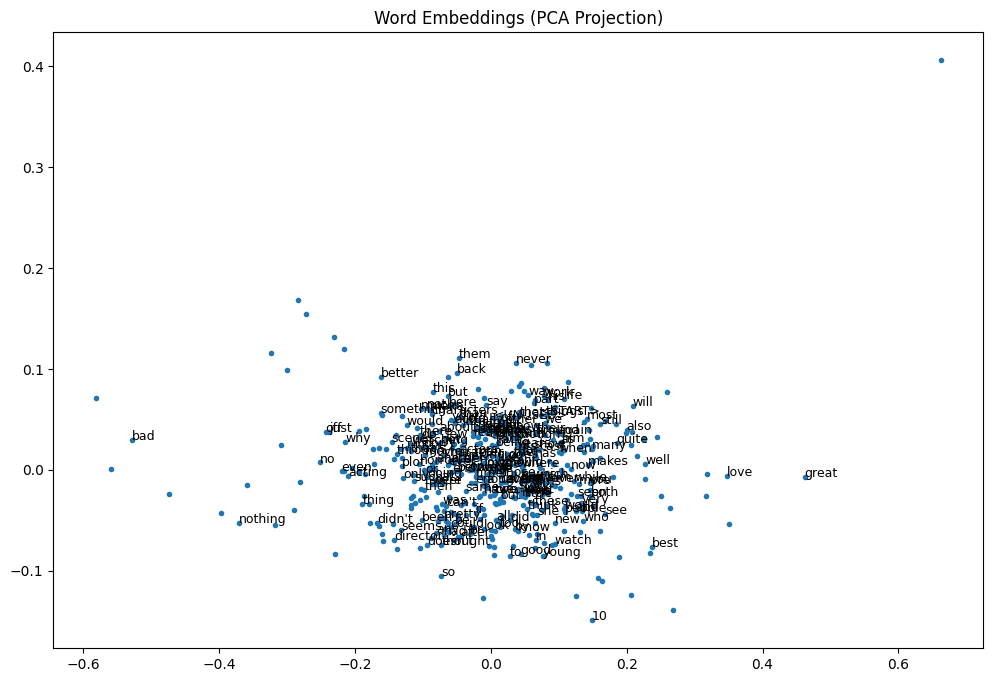

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

# 1. Load IMDB dataset
max_features = 10000
maxlen = 200
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)
x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)

# 2. Build simple model with embedding
model = Sequential([
    Embedding(input_dim=max_features, output_dim=128, input_length=maxlen, name="embedding"),
    SimpleRNN(64, activation="tanh"),
    Dense(1, activation="sigmoid")
])
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.fit(x_train, y_train, epochs=1, batch_size=512, validation_split=0.2)

# 3. Extract embedding weights
embedding_layer = model.get_layer("embedding")
embedding_weights = embedding_layer.get_weights()[0]   # shape: (10000, 128)

# 4. Reduce dimensions (PCA)
pca = PCA(n_components=2)
reduced = pca.fit_transform(embedding_weights[:500])  # take first 500 words

# 5. Get word index and reverse map
word_index = imdb.get_word_index()
reverse_word_index = {value+3: key for key, value in word_index.items()}
reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"
reverse_word_index[3] = "<UNUSED>"

# 6. Plot
plt.figure(figsize=(12, 8))
plt.scatter(reduced[:,0], reduced[:,1], marker='.')
for i in range(1, 200):  # label first 200 words
    plt.text(reduced[i,0], reduced[i,1], reverse_word_index.get(i, "?"), fontsize=9)
plt.title("Word Embeddings (PCA Projection)")
plt.show()


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 500 samples in 0.001s...
[t-SNE] Computed neighbors for 500 samples in 0.225s...
[t-SNE] Computed conditional probabilities for sample 500 / 500
[t-SNE] Mean sigma: 0.095172
[t-SNE] KL divergence after 250 iterations with early exaggeration: 63.094025
[t-SNE] KL divergence after 2000 iterations: 1.846660


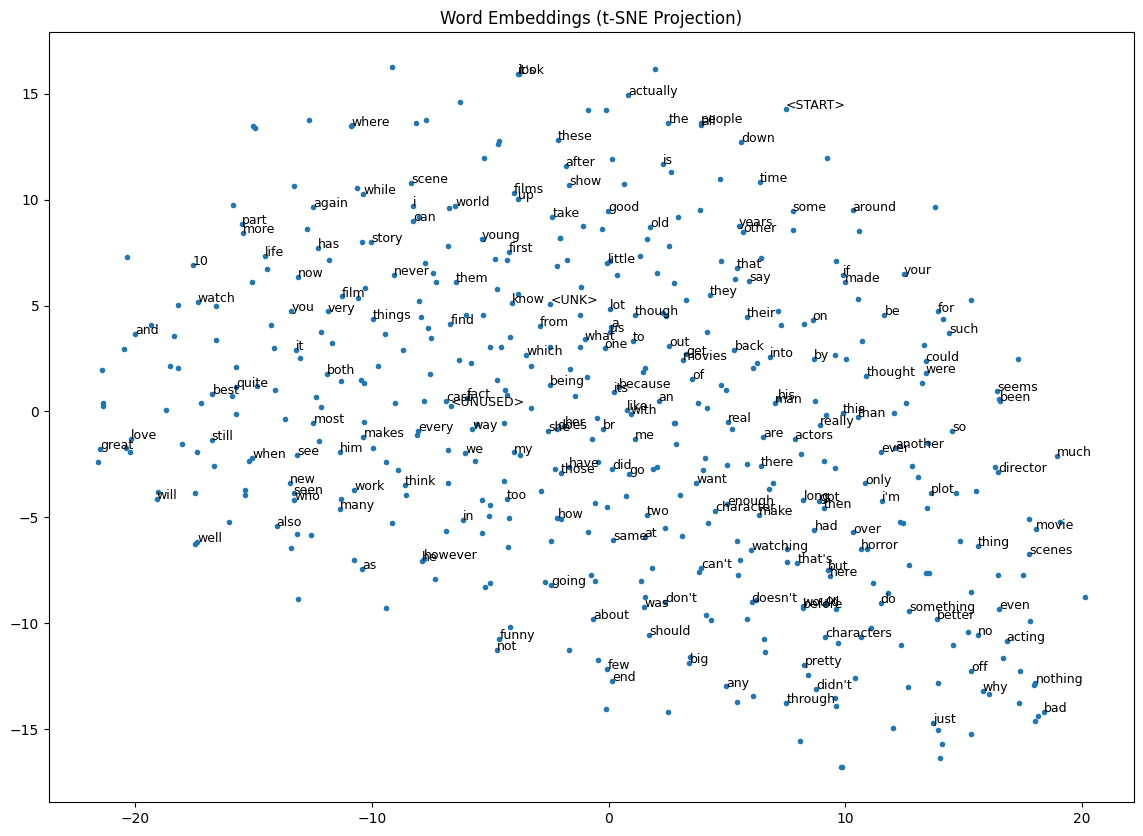

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

# 3. Extract embedding weights
embedding_layer = model.get_layer("embedding")
embedding_weights = embedding_layer.get_weights()[0]   # shape: (10000, 128)

# 4. Reduce dimensions with t-SNE (use first 500 words for speed)
tsne = TSNE(n_components=2, perplexity=30, n_iter=2000, random_state=42, verbose=1)
reduced = tsne.fit_transform(embedding_weights[:500])

# 5. Reverse word index
word_index = imdb.get_word_index()
reverse_word_index = {value+3: key for key, value in word_index.items()}
reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"
reverse_word_index[3] = "<UNUSED>"

# 6. Plot
plt.figure(figsize=(14, 10))
plt.scatter(reduced[:, 0], reduced[:, 1], marker='.')
for i in range(1, 200):  # annotate first 200 words
    plt.text(reduced[i, 0], reduced[i, 1], reverse_word_index.get(i, "?"), fontsize=9)
plt.title("Word Embeddings (t-SNE Projection)")
plt.show()